# Exercise with numbers

In [40]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision as vision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor

import matplotlib.pyplot as plt

import numpy as np

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from helper_functions import *

import kagglehub as kg

torch.set_default_device("cpu")

print(f"Torch: {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print(f"KaggleHub: {kg.__version__}")

!nvidia-smi

Torch: 2.7.1
TorchVision: 0.22.1
KaggleHub: 0.3.12
zsh:1: command not found: nvidia-smi


In [41]:
# getting the data
# MORE: lets try to use EMNIST to find digits
# Download latest version
# path = kg.dataset_download("hojjatk/mnist-dataset")

# print("Path to dataset files:", path)

In [42]:
train_data = torchvision.datasets.MNIST(
    root="~/.cache/datasets/mnistNumbers",
    train=True,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

test_data = torchvision.datasets.MNIST(
    root="~/.cache/datasets/mnistNumbers",
    train=False,
    download=True,
    transform=ToTensor(),
    target_transform=None
)

TrainDataLen: 60000
TestDataLen: 10000


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

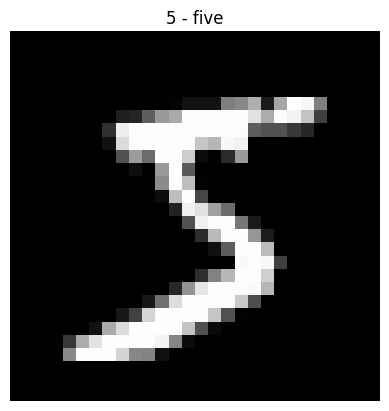

In [43]:
print(f"TrainDataLen: {len(train_data)}")
print(f"TestDataLen: {len(test_data)}")
image, label = train_data[0]
class_names = train_data.classes
plt.imshow(image.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

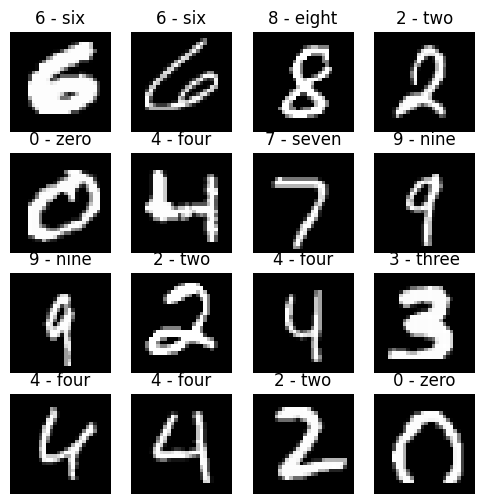

In [44]:
# Plot more images
torch.manual_seed(42)
fig = plt.figure(figsize=(6, 6))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i) # i is the index
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(class_names[label])
    plt.axis(False)

In [45]:
# Devide the data into batches
from torch.utils.data import DataLoader
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset=train_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=test_data, batch_size=BATCH_SIZE, shuffle=False)
print(train_dataloader)

(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

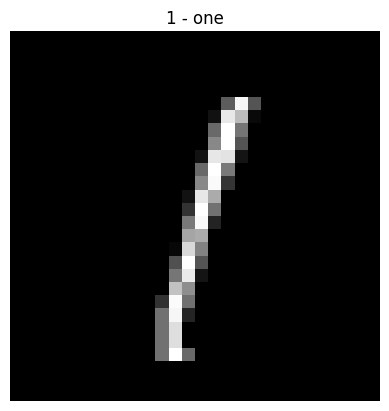

In [46]:
train_features_batch, train_label_batch = next(iter(train_dataloader))
test_features_batch, test_label_betch = next(iter(test_dataloader))
random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_label_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(class_names[label])
plt.axis(False)

In [47]:
from helper_functions import accuracy_fn as not_my_acc_fn

# Create a function to time out experiments
from timeit import default_timer as timer

def print_train_time(start : float, end: float, device: torch.device = None):
    total_time = end - start
    print(f"Train time on {device}: {total_time:.3f} seconds")

def train_model(model: nn.Module, loss_fn, optimizer, train_dataloader, epochs, accuracy_fn):
    # # Training on batches
    from tqdm.auto import tqdm # Progress bar
    torch.manual_seed(42)
    start = timer()
    for ep in tqdm(range(epochs)):
        train_loss = 0
        train_acc = 0
        model.train()
        for batch, (X, y) in enumerate(train_dataloader):
            # Logits
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            train_loss += loss
            acc = accuracy_fn(y, y_pred=y_pred.argmax(dim=1))
            train_acc += acc

            # Zero Grad
            optimizer.zero_grad()
            # backpropagation
            loss.backward()
            # This is doint once per batch
            optimizer.step()

        # Device train loass
        train_acc /= len(train_dataloader)
        train_loss /= len(train_dataloader)

        print(f"Epoch: {ep} | TrainLoss: {train_loss}, TrainAcc : {train_acc}")    

    end = timer()
    return model

def eval_model(model, data_loader: torch.utils.data.DataLoader, loss_fn: torch.nn.Module, acc_fn):
    loss, acc = 0, 0
    model.eval()
    test_loss = 0.0
    test_acc = 0
    len_l = len(data_loader)
    with torch.inference_mode():
        for X_test, y_test in data_loader:
            test_pred = model(X_test)
            loss = loss_fn(test_pred, y_test)
            test_loss += loss
            acc = acc_fn(y_test, test_pred.argmax(dim=1))
            test_acc += acc
            
    test_loss = test_loss * (1 / len_l)
    test_acc /= len_l

    return {"model_name" : model.__class__.__name__,
        "model_loss": test_loss.item(), "model_acc": test_acc}

In [48]:
# Model 0
class NumberMNIST0(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=input_shape, out_features=hidden_units),
            # nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model = NumberMNIST0(inf, 32, len(class_names))

# Loss and Optim
loss_fn = nn.CrossEntropyLoss() 
optimizer = optim.SGD(params=model.parameters(), lr = 0.03)

# Train
my_trained = train_model(model, loss_fn, optimizer, train_dataloader, 20, not_my_acc_fn)

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 0 | TrainLoss: 0.5541462302207947, TrainAcc : 85.80333333333333
Epoch: 1 | TrainLoss: 0.29196861386299133, TrainAcc : 91.68833333333333
Epoch: 2 | TrainLoss: 0.24632558226585388, TrainAcc : 92.94833333333334
Epoch: 3 | TrainLoss: 0.21370740234851837, TrainAcc : 93.88
Epoch: 4 | TrainLoss: 0.18990106880664825, TrainAcc : 94.47166666666666
Epoch: 5 | TrainLoss: 0.17067958414554596, TrainAcc : 95.02666666666667
Epoch: 6 | TrainLoss: 0.15597985684871674, TrainAcc : 95.44
Epoch: 7 | TrainLoss: 0.1443047970533371, TrainAcc : 95.795
Epoch: 8 | TrainLoss: 0.1343163251876831, TrainAcc : 96.095
Epoch: 9 | TrainLoss: 0.12518835067749023, TrainAcc : 96.34666666666666
Epoch: 10 | TrainLoss: 0.11825169622898102, TrainAcc : 96.54666666666667
Epoch: 11 | TrainLoss: 0.11189772933721542, TrainAcc : 96.76166666666667
Epoch: 12 | TrainLoss: 0.10664694756269455, TrainAcc : 96.905
Epoch: 13 | TrainLoss: 0.1009342297911644, TrainAcc : 97.08166666666666
Epoch: 14 | TrainLoss: 0.0966213271021843, TrainA

In [49]:
model_0_results = eval_model(
    model=my_trained, 
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    acc_fn=not_my_acc_fn
)
print(f"{model_0_results["model_name"]}| TestAcc: {(model_0_results['model_acc']):.2f}%")

NumberMNIST0| TestAcc: 96.71%


0.0


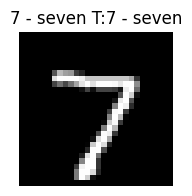

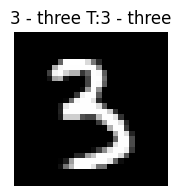

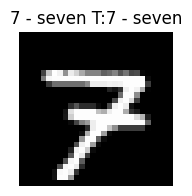

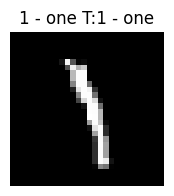

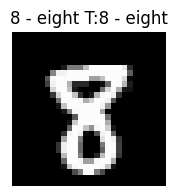

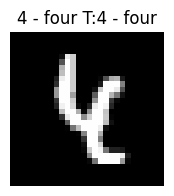

In [50]:
def print_img(model, data_loader):
    index = 0
    acc_sum = 0
    for X, l in data_loader:
        img = X
        pred = model(X)
        pred = pred.argmax(dim=1)
        label = pred[0]
        #Plot more images
        torch.manual_seed(42)
        fig = plt.figure(figsize=(2, 2))
        #random_idx = torch.randint(0, , size=[1]).item()
        plt.imshow(img[0].squeeze(), cmap="gray")
        plt.title(f"{class_names[label]} T:{class_names[l[0]]}")
        plt.axis(False)
        index+=1
        if index > 5:
            break
    print(acc_sum / len(data_loader))

# Printing
print_img(my_trained, test_dataloader)

In [51]:
# CNN Model
class NumberMNISTCNN(nn.Module):
    """We are copying the TinyVGG"""
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5),
            nn.MaxPool2d(2),
            # nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5),
            # nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Linear(in_features=1152, out_features=hidden_units),
            # nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model_cnn = NumberMNISTCNN(inf, 32, len(class_names))
print(model_cnn)

# Loss and Optim
loss_fn = nn.CrossEntropyLoss() 
optimizer = optim.SGD(params=model_cnn.parameters(), lr = 0.03)

# Train
my_trained_cnn = train_model(model_cnn, loss_fn, optimizer, train_dataloader, 1, not_my_acc_fn)

NumberMNISTCNN(
  (layer_stack): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Flatten(start_dim=1, end_dim=-1)
    (3): Linear(in_features=1152, out_features=32, bias=True)
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)


  0%|          | 0/1 [00:00<?, ?it/s]

Epoch: 0 | TrainLoss: 0.4054458737373352, TrainAcc : 88.51666666666667


In [52]:
model_cnn_results = eval_model(
    model=my_trained_cnn, 
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    acc_fn=not_my_acc_fn
)
print(f"{model_cnn_results["model_name"]}| TestAcc: {(model_cnn_results['model_acc']):.2f}%")

NumberMNISTCNN| TestAcc: 93.00%


![Just keep smiling]( https://cdn.analyticsvidhya.com/wp-content/uploads/2020/10/90650dnn2-1536x822.webp "TinyVGG")

In [53]:
# CNN Model
class NumberMNISTCNN_2(nn.Module):
    """We are copying the TinyVGG"""
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.layer_stack = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=8, kernel_size=5),
            nn.MaxPool2d(2),
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5),
            nn.MaxPool2d(2),
            nn.Flatten(),
            nn.ReLU(),
            nn.Linear(in_features=256, out_features=hidden_units),
            nn.Linear(in_features=hidden_units, out_features=output_shape),
        )

    def forward(self, x):
        return self.layer_stack(x)

inf = (len(nn.Flatten()(img).squeeze()))
model_cnn_2 = NumberMNISTCNN_2(inf, 32, len(class_names))
print(model_cnn_2)

# Loss and Optim
loss_fn = nn.CrossEntropyLoss() 
optimizer = optim.SGD(params=model_cnn_2.parameters(), lr = 0.03)

# Train
my_trained_cnn_2 = train_model(model_cnn_2, loss_fn, optimizer, train_dataloader, 10, not_my_acc_fn)

NumberMNISTCNN_2(
  (layer_stack): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (2): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Flatten(start_dim=1, end_dim=-1)
    (5): ReLU()
    (6): Linear(in_features=256, out_features=32, bias=True)
    (7): Linear(in_features=32, out_features=10, bias=True)
  )
)


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 0 | TrainLoss: 0.3554815948009491, TrainAcc : 89.27666666666667
Epoch: 1 | TrainLoss: 0.09788483381271362, TrainAcc : 96.97833333333334
Epoch: 2 | TrainLoss: 0.07729333639144897, TrainAcc : 97.60833333333333
Epoch: 3 | TrainLoss: 0.06674675643444061, TrainAcc : 97.91666666666667
Epoch: 4 | TrainLoss: 0.058438774198293686, TrainAcc : 98.215
Epoch: 5 | TrainLoss: 0.05259343236684799, TrainAcc : 98.32833333333333
Epoch: 6 | TrainLoss: 0.048561859875917435, TrainAcc : 98.485
Epoch: 7 | TrainLoss: 0.04472571611404419, TrainAcc : 98.59166666666667
Epoch: 8 | TrainLoss: 0.04175758361816406, TrainAcc : 98.65166666666667
Epoch: 9 | TrainLoss: 0.038231462240219116, TrainAcc : 98.78


In [54]:
model_cnn_results_2 = eval_model(
    model=my_trained_cnn_2, 
    data_loader=test_dataloader,
    loss_fn=loss_fn, 
    acc_fn=not_my_acc_fn
)
print(f"{model_cnn_results_2["model_name"]}| TestAcc: {(model_cnn_results_2['model_acc']):.2f}%")

NumberMNISTCNN_2| TestAcc: 98.49%


In [55]:
# TODO: I need to test training on gpu, cpu is too slow for images
import torch
import torch.nn as nn
torch.manual_seed(42)

images = torch.randn(size=(3, 64, 64))


In [56]:
max_pol_layer = nn.MaxPool2d(2)
conv_layer = nn.Conv2d(3, 10, 3, 1, 0)

In [57]:
out = conv_layer(images)

In [58]:
print(out.size())

torch.Size([10, 62, 62])


In [59]:
max_out = max_pol_layer(out)

In [60]:
import matplotlib.pyplot as plt

In [61]:
print(max_out.shape)

torch.Size([10, 31, 31])
